In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

CITY_NAME = "Islamabad"

AQI_CATEGORY_COLORS = {
    "Good": "#00E400",
    "Moderate": "#FFFF00",
    "Unhealthy for Sensitive Groups": "#FF7E00",
    "Unhealthy": "#FF0000",
    "Very Unhealthy": "#8F3F97",
    "Hazardous": "#7E0023",
}

def categorize_aqi(v):
    if v <= 50: return "Good"
    if v <= 100: return "Moderate"
    if v <= 150: return "Unhealthy for Sensitive Groups"
    if v <= 200: return "Unhealthy"
    if v <= 300: return "Very Unhealthy"
    return "Hazardous"

In [3]:
df = pd.read_csv("/content/data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["month_name"] = df["timestamp"].dt.month_name()
df["day_name"] = df["timestamp"].dt.day_name()
df["aqi_category"] = df["aqi"].apply(categorize_aqi)
df = df.sort_values("timestamp").reset_index(drop=True)

agg_cols = [
    "aqi", "pm25_median", "pm10_median", "o3_median", "no2_median",
    "so2_median", "co_median", "temperature_median", "humidity_median",
    "pressure_median", "wind_speed_median",
]

print(f"Rows: {len(df)}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
df.head()

Rows: 725
Date range: 2024-08-24 to 2026-08-24


,date,pm25_median,pm10_median,o3_median,no2_median,so2_median,co_median,temperature_median,humidity_median,pressure_median,...,hour_of_day,day_of_week,month,is_weekend,aqi_change_rate,rolling_avg_aqi_3d,rolling_avg_aqi_7d,month_name,day_name,aqi_category
0,2024-08-24,41.980,58.690,125.890,8.050,5.480,807.760,28.65,69.5,944.05,...,0,5,8,1,NaN,117.000000,117.0,August,Saturday,Unhealthy for Sensitive Groups
1,2024-08-25,32.135,44.105,75.100,9.810,2.575,694.275,27.45,80.5,942.65,...,0,6,8,1,-24.0,105.000000,105.0,August,Sunday,Moderate
2,2024-08-26,27.845,41.975,65.805,11.995,2.545,767.705,28.10,72.0,942.10,...,0,0,8,0,-9.0,98.000000,98.0,August,Monday,Moderate
3,2024-08-27,39.150,54.485,49.355,22.960,1.270,1214.980,25.35,85.0,945.40,...,0,1,8,0,26.0,95.666667,101.0,August,Tuesday,Unhealthy for Sensitive Groups
4,2024-08-28,45.595,67.090,32.005,24.850,1.880,1355.170,25.00,85.5,944.20,...,0,2,8,0,16.0,106.666667,106.0,August,Wednesday,Unhealthy for Sensitive Groups


In [4]:
print("Missing values per column:")
print(df[agg_cols].isna().sum())
print("\nSummary statistics:")
df[agg_cols].describe()

Missing values per column:
aqi                   0
pm25_median           0
pm10_median           0
o3_median             0
no2_median            0
so2_median            0
co_median             0
temperature_median    0
humidity_median       0
pressure_median       0
wind_speed_median     0
dtype: int64

Summary statistics:


,aqi,pm25_median,pm10_median,o3_median,no2_median,so2_median,co_median,temperature_median,humidity_median,pressure_median,wind_speed_median
count,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000
mean,139.645517,68.421910,99.745766,75.181193,17.148503,3.516034,809.460959,20.143655,64.498621,946.679241,4.898483
std,64.174571,65.737848,82.513406,22.591132,8.818431,1.626492,396.408420,7.552855,15.784591,5.095442,1.475113
min,25.000000,6.020000,8.470000,13.500000,2.845000,0.505000,236.820000,6.100000,20.500000,935.650000,1.900000
25%,96.000000,33.340000,52.360000,59.815000,10.400000,2.365000,544.300000,12.750000,54.500000,942.450000,4.000000
50%,136.000000,49.415000,74.775000,70.710000,15.680000,3.210000,706.240000,21.650000,65.500000,946.750000,4.650000
75%,160.000000,73.180000,110.885000,89.595000,21.935000,4.335000,967.980000,26.600000,77.500000,950.950000,5.500000
max,498.000000,497.170000,568.745000,157.100000,47.985000,11.735000,2785.940000,34.900000,94.000000,957.950000,13.200000


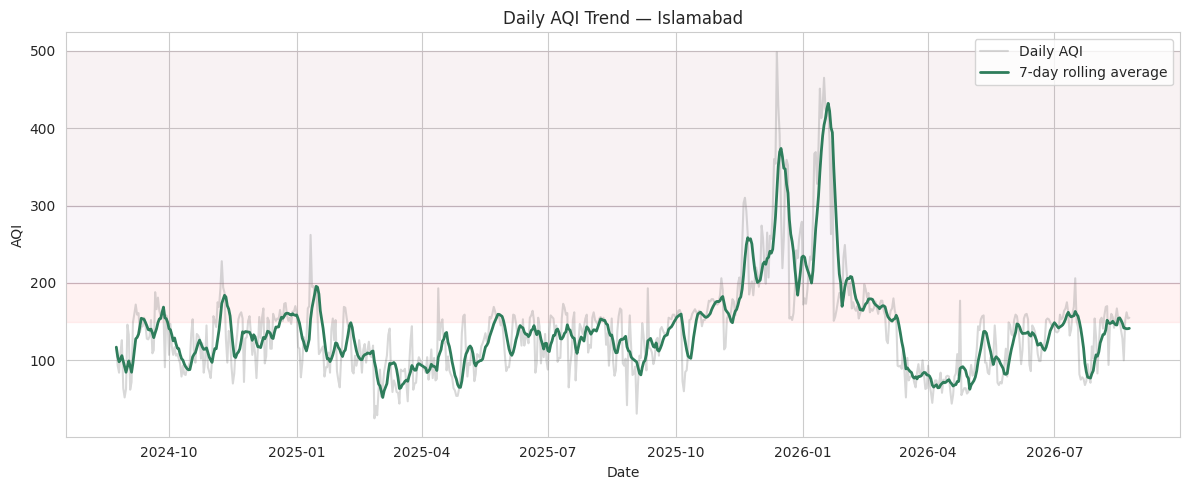

In [5]:
df["rolling_7d"] = df["aqi"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(df["timestamp"], df["aqi"], alpha=0.3, label="Daily AQI", color="gray")
ax.plot(df["timestamp"], df["rolling_7d"], label="7-day rolling average", color="#2E7D5B", linewidth=2)
for lo, hi, color in [(150, 200, "#FF0000"), (200, 300, "#8F3F97"), (300, 500, "#7E0023")]:
    ax.axhspan(lo, hi, color=color, alpha=0.05)
ax.set_title(f"Daily AQI Trend — {CITY_NAME}")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.legend()
plt.tight_layout()
plt.show()

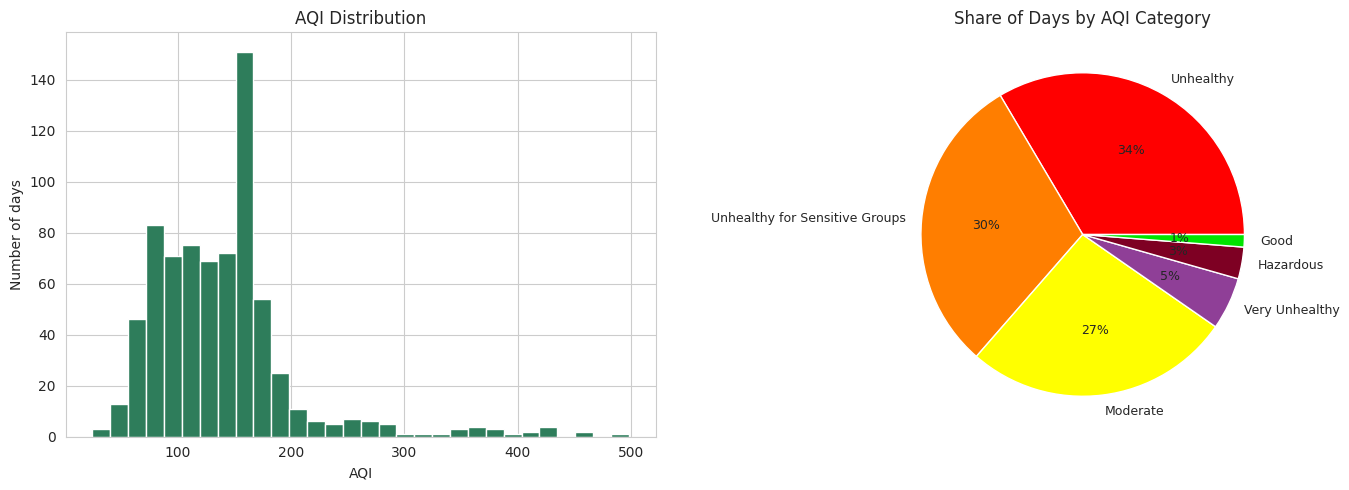

aqi_category
Unhealthy                         243
Unhealthy for Sensitive Groups    218
Moderate                          194
Very Unhealthy                     38
Hazardous                          23
Good                                9
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["aqi"], bins=30, color="#2E7D5B", edgecolor="white")
axes[0].set_title("AQI Distribution")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of days")

category_counts = df["aqi_category"].value_counts()
colors = [AQI_CATEGORY_COLORS[c] for c in category_counts.index]
axes[1].pie(category_counts, labels=category_counts.index, autopct="%1.0f%%", colors=colors, textprops={"fontsize": 9})
axes[1].set_title("Share of Days by AQI Category")

plt.tight_layout()
plt.show()

print(category_counts)

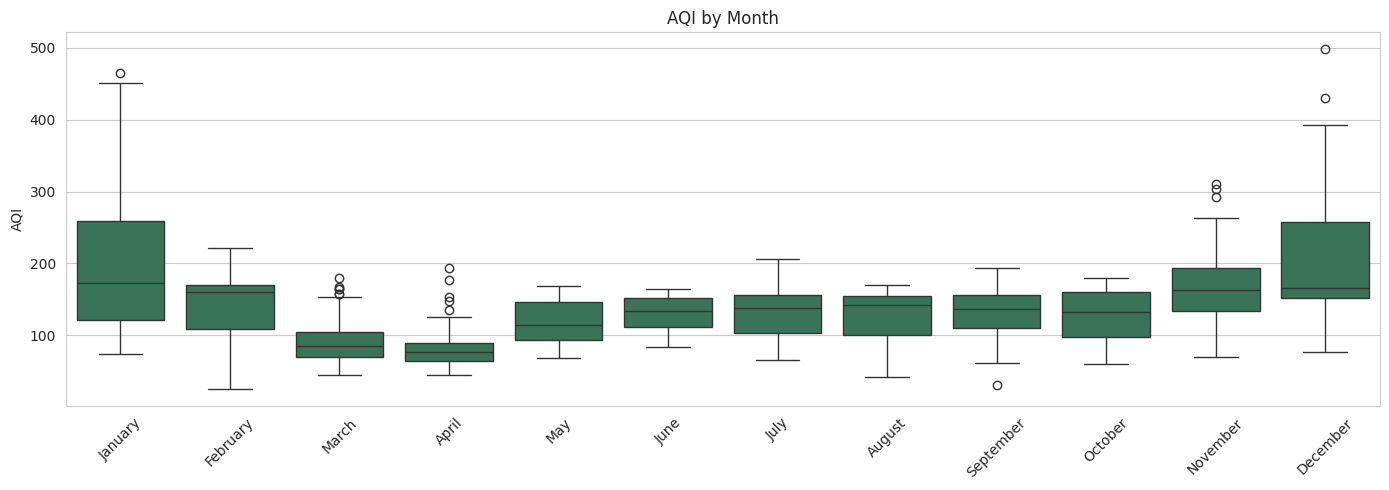

In [7]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df, x="month_name", y="aqi", order=month_order, ax=ax, color="#2E7D5B")
ax.set_title("AQI by Month")
ax.set_xlabel("")
ax.set_ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

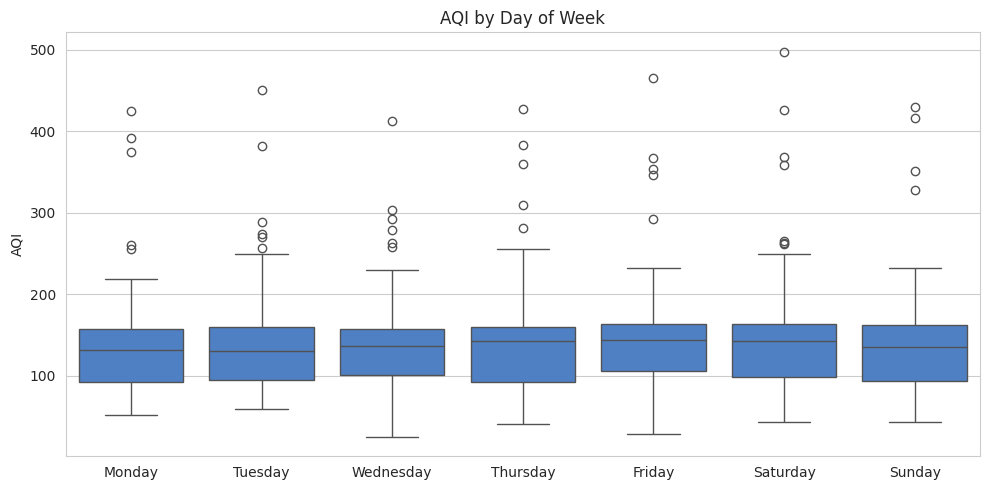

In [8]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="day_name", y="aqi", order=day_order, ax=ax, color="#3B7DD8")
ax.set_title("AQI by Day of Week")
ax.set_xlabel("")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.show()

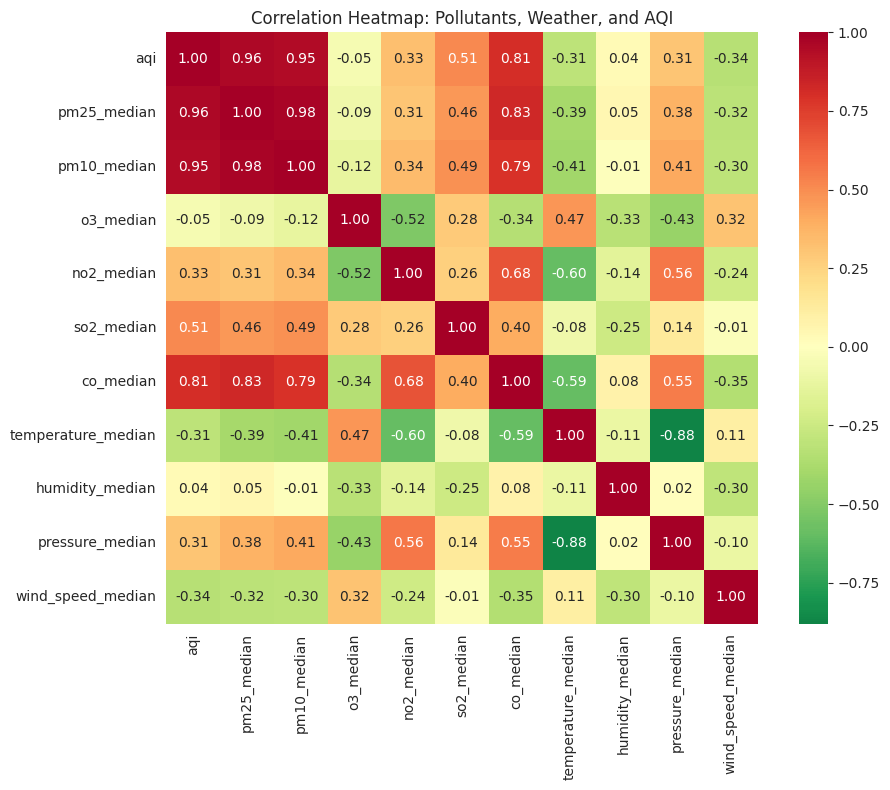

Correlation with AQI, sorted:
aqi                   1.000000
pm25_median           0.959994
pm10_median           0.946817
co_median             0.805249
so2_median            0.512744
no2_median            0.331268
pressure_median       0.305569
humidity_median       0.035297
o3_median            -0.050640
temperature_median   -0.314222
wind_speed_median    -0.335094
Name: aqi, dtype: float64


In [9]:
corr_matrix = df[agg_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap: Pollutants, Weather, and AQI")
plt.tight_layout()
plt.show()

print("Correlation with AQI, sorted:")
print(corr_matrix["aqi"].sort_values(ascending=False))

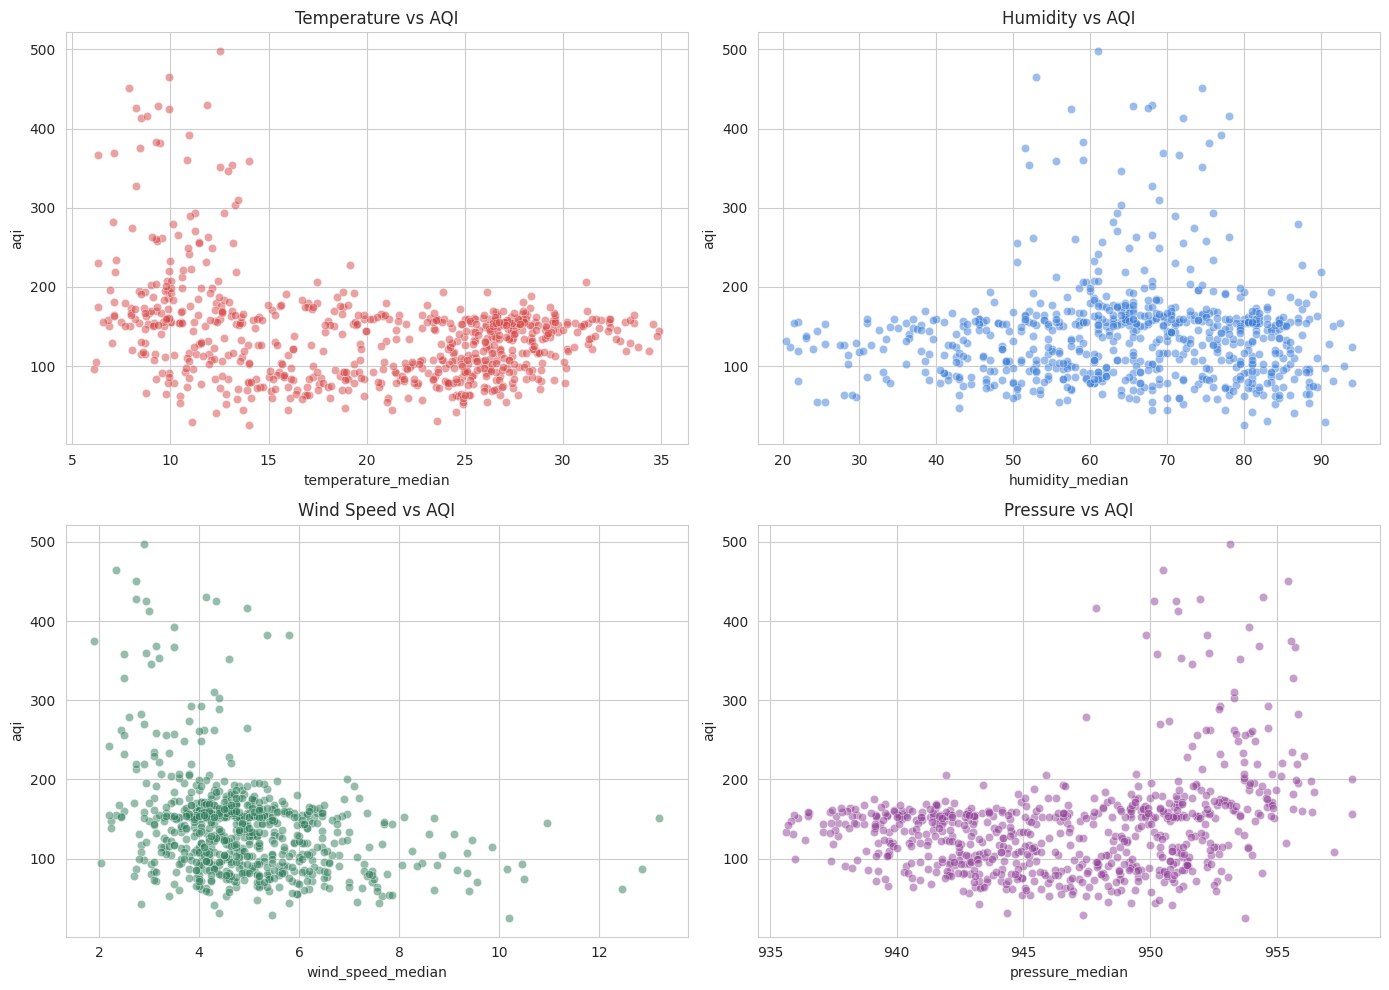

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="temperature_median", y="aqi", ax=axes[0,0], alpha=0.5, color="#D64545")
axes[0,0].set_title("Temperature vs AQI")

sns.scatterplot(data=df, x="humidity_median", y="aqi", ax=axes[0,1], alpha=0.5, color="#3B7DD8")
axes[0,1].set_title("Humidity vs AQI")

sns.scatterplot(data=df, x="wind_speed_median", y="aqi", ax=axes[1,0], alpha=0.5, color="#2E7D5B")
axes[1,0].set_title("Wind Speed vs AQI")

sns.scatterplot(data=df, x="pressure_median", y="aqi", ax=axes[1,1], alpha=0.5, color="#8F3F97")
axes[1,1].set_title("Pressure vs AQI")

plt.tight_layout()
plt.show()

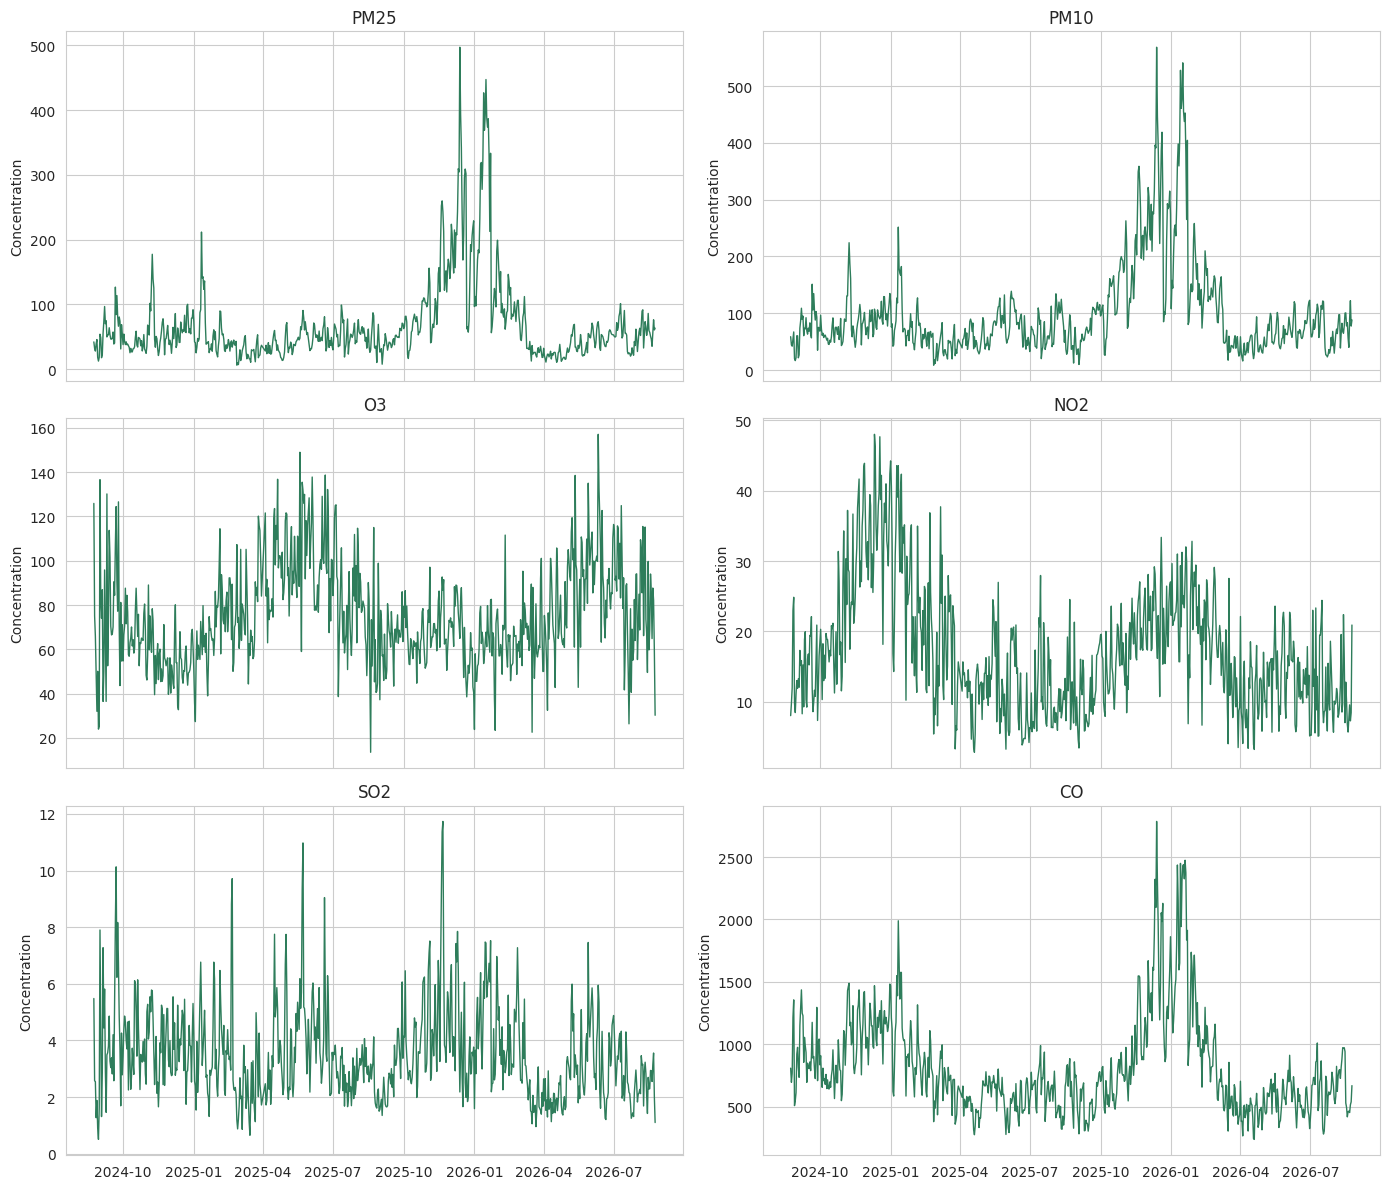

In [11]:
pollutants = ["pm25_median", "pm10_median", "o3_median", "no2_median", "so2_median", "co_median"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for ax, col in zip(axes.flatten(), pollutants):
    ax.plot(df["timestamp"], df[col], color="#2E7D5B", linewidth=1)
    ax.set_title(col.replace("_median", "").upper())
    ax.set_ylabel("Concentration")

plt.tight_layout()
plt.show()

In [12]:
dominant_pollutant = df[pollutants].corrwith(df["aqi"]).sort_values(ascending=False)
print("Correlation of each pollutant with AQI (highest = most dominant driver):")
print(dominant_pollutant)

Correlation of each pollutant with AQI (highest = most dominant driver):
pm25_median    0.959994
pm10_median    0.946817
co_median      0.805249
so2_median     0.512744
no2_median     0.331268
o3_median     -0.050640
dtype: float64


In [13]:
worst_month = df.groupby("month_name")["aqi"].mean().idxmax()
best_month = df.groupby("month_name")["aqi"].mean().idxmin()
weekday_avg = df[df["day_of_week"] < 5]["aqi"].mean()
weekend_avg = df[df["day_of_week"] >= 5]["aqi"].mean()

print(f"Worst AQI month (avg): {worst_month}")
print(f"Best AQI month (avg): {best_month}")
print(f"Weekday avg AQI: {weekday_avg:.1f}")
print(f"Weekend avg AQI: {weekend_avg:.1f}")
print(f"Most correlated pollutant with AQI: {dominant_pollutant.index[0]} ({dominant_pollutant.iloc[0]:.3f})")
print(f"\nAQI category breakdown:\n{category_counts}")

Worst AQI month (avg): January
Best AQI month (avg): April
Weekday avg AQI: 139.1
Weekend avg AQI: 141.1
Most correlated pollutant with AQI: pm25_median (0.960)

AQI category breakdown:
aqi_category
Unhealthy                         243
Unhealthy for Sensitive Groups    218
Moderate                          194
Very Unhealthy                     38
Hazardous                          23
Good                                9
Name: count, dtype: int64
